# Fourier Burst Accumulation (FBA) — Pipeline de restauración + métricas

## El método
*Lucky imaging en el dominio de la frecuencia.* La turbulencia atenúa distintas frecuencias en distintos frames. FBA reconstruye **cada frecuencia por separado**, ponderando los frames donde esa frecuencia sobrevivió:

$$\hat{u}(\zeta) = \sum_{i} w_i(\zeta)\, U_i(\zeta), \qquad w_i(\zeta) = \frac{\big(G_\sigma * |U_i|\big)^{p}}{\sum_j \big(G_\sigma * |U_j|\big)^{p}}$$

con $U_i = \mathcal{F}\{u_i\}$ la FFT del frame, $G_\sigma$ un suavizado gaussiano de la magnitud (clave para no amplificar ruido) y $p$ la selectividad. *(Delbracio & Sapiro, IEEE TIP 2015.)*

## Qué hace
1. Lee **todos los `.fits`** de `Dataset/` (una subcarpeta por persona).
2. Por cada cubo: registra los frames y aplica FBA → **imagen mejorada**.
3. Guarda la imagen como **PNG** en una carpeta `fba_<persona>`.
4. Calcula **MSE / PSNR / SSIM** vs MFBD con el mismo procedimiento de `Solarius_joshe/metricas.py`.
5. Exporta un **CSV de métricas por carpeta**.

## Salida
```
resultados_fba/
├── fba_benja/   chromosphere_100p_00100.png … + metricas_fba_benja.csv
├── fba_joaco/   continuum_200p_00100.png …   + metricas_fba_joaco.csv
├── fba_joshe/   …
├── fba_nayely/  …
└── fba_extra/   …
```

### Explicación de cada variable de la función

**Fórmula:**
$$\hat{u}(\zeta) = \sum_{i} w_i(\zeta)\, U_i(\zeta), \qquad w_i(\zeta) = \frac{\big(G_\sigma * |U_i|\big)^{p}}{\sum_j \big(G_\sigma * |U_j|\big)^{p}}$$

#### 1. Variables de la fórmula

| Símbolo | Nombre | Qué es |
|---|---|---|
| $u_i$ | frame $i$ | La imagen cruda número $i$ del cubo (uno de los 100/200 frames). |
| $i$ | índice de frame | Recorre todos los frames ($i = 1,\dots,T$). |
| $\mathcal{F}$ | transformada de Fourier | Operador FFT: pasa del dominio espacial al de frecuencia. |
| $U_i = \mathcal{F}\{u_i\}$ | espectro del frame $i$ | La FFT del frame: un número **complejo** por frecuencia (amplitud + fase). |
| $\zeta$ (zeta) | frecuencia espacial | Coordenada en Fourier. $\zeta$ chico = estructura grande/suave; $\zeta$ grande = detalle fino. |
| $U_i(\zeta)$ | espectro en una frecuencia | Valor complejo del frame $i$ **en esa frecuencia puntual** $\zeta$. |
| $\lvert U_i \rvert$ | magnitud (amplitud) | Cuánta energía tiene el frame en cada frecuencia. **Indica si esa frecuencia "sobrevivió" a la turbulencia.** |
| $G_\sigma$ | núcleo gaussiano | Filtro de suavizado de ancho $\sigma$. |
| $*$ | convolución | $G_\sigma * \lvert U_i\rvert$ = magnitud **suavizada** (evita que el ruido de alta frecuencia domine los pesos). |
| $\sigma$ (sigma) | ancho del suavizado | Cuánto se promedian las frecuencias vecinas al calcular el peso. |
| $p$ | selectividad | Exponente del reparto. $p$ alto → casi solo el mejor frame por frecuencia; $p=0$ → promedio uniforme. |
| $w_i(\zeta)$ | peso | Cuánto aporta el frame $i$ **en la frecuencia $\zeta$**. Normalizado: $\sum_i w_i(\zeta) = 1$. |
| $j$ | índice del denominador | Recorre todos los frames para normalizar los pesos (que sumen 1). |
| $\hat{u}(\zeta)$ | espectro reconstruido | En cada frecuencia, la suma ponderada de los frames. La imagen restaurada es su FFT inversa: $u = \mathcal{F}^{-1}\{\hat{u}\}$. |

**Idea en una frase:** para cada frecuencia $\zeta$, los frames donde esa frecuencia es fuerte (magnitud suavizada alta) reciben más peso $w_i$, y el espectro final $\hat{u}$ es esa mezcla ponderada.

#### 2. Cómo se traduce al código (`restore_fba`)

| Fórmula | Código |
|---|---|
| $u_i$ (los frames) | `data` |
| $T$ (nº de frames) | `T` en `T, H, W = data.shape` |
| $U_i = \mathcal{F}\{u_i\}$ | `U = fft2(data, axes=(1,2))` |
| $\lvert U_i\rvert$ | `mag = np.abs(U)` |
| $\sigma$ | `sigma = sigma_frac * max(H, W)` |
| $G_\sigma * \lvert U_i\rvert$ | `mag_s[t] = ...gaussian_filter(...mag[t]..., sigma)` |
| $(G_\sigma*\lvert U_i\rvert)^p$ | `w = (mag_s / mmax) ** p` (con `/mmax` para no desbordar) |
| $\div \sum_j(\dots)^p$ | `w /= w.sum(axis=0)` (normalización → $w_i$) |
| $\sum_i w_i(\zeta)\,U_i(\zeta)$ | `U_agg = (w * U).sum(axis=0)` ($\hat{u}$) |
| $u=\mathcal{F}^{-1}\{\hat{u}\}$ | `restored = np.real(ifft2(U_agg))` |

#### 3. Parámetros (argumentos) de la función

| Parámetro | Default | Qué controla |
|---|---|---|
| `cube` | — | Cubo `(T, H, W)` de entrada. |
| `p` ($=p$) | `11` | **Selectividad** de la fórmula (elige más o menos agresivamente el mejor frame por frecuencia). |
| `sigma_frac` | `0.045` | Define $\sigma = $ `sigma_frac · tamaño`. Más alto = suavizado de pesos más fuerte (menos ruido, menos detalle). |
| `keep_frac` | `0.5` | Fracción de frames más nítidos a usar (lucky imaging). No está en la fórmula; es la optimización que acelera sin perder calidad. |
| `upsample` | `3` | Precisión sub-pixel del **registro** (paso previo, no es parte de la fórmula FBA). |
| `register` | `True` | Si re-alinea los frames antes de agregar (corrige el tip-tilt). |

Los dos primeros (`p`, `sigma_frac`) son **los de la fórmula matemática**; los otros tres pertenecen al *pre-procesado* (selección y alineación de frames) que rodea al núcleo FBA.

## 1. Imports y configuración

In [2]:
import os
import re
import time
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from PIL import Image

from numpy.fft import fft2, ifft2, fftshift, ifftshift
from scipy.ndimage import gaussian_filter, shift as nd_shift, laplace
from skimage.registration import phase_cross_correlation
from skimage.feature import match_template
from skimage.metrics import (mean_squared_error,
                             peak_signal_noise_ratio,
                             structural_similarity)

# ---------------------------------------------------------------------------
# Configuración
# ---------------------------------------------------------------------------
DATASET_ROOT = Path('Dataset')           # carpeta con subcarpetas por persona
OUTPUT_ROOT  = Path('Solarius_benja')    # raíz de salidas (PNG + CSV)
METHOD       = 'fba'                       # prefijo de las carpetas de salida

# Parámetros FBA
FBA_P          = 11      # selectividad por frecuencia (más alto = más "lucky")
FBA_SIGMA_FRAC = 0.045   # sigma del suavizado gaussiano de pesos, relativo al tamaño
FBA_KEEP_FRAC  = 0.5     # fracción de frames más nítidos a usar (lucky imaging):
                          #   <1.0 acelera y NO baja la calidad (incluso la mejora).
                          #   1.0 = usar todos los frames.
FBA_UPSAMPLE   = 3       # sub-pixel del registro (bajarlo de 10 a 3 casi no cambia nada)

# Paralelismo: los cubos se procesan en threads (numpy/scipy liberan el GIL).
N_WORKERS = min(6, os.cpu_count() or 4)

# Alias corto por subcarpeta del dataset (los mismos que usa el equipo)
PERSON_SHORTNAME = {
    'Dataset - Benjamin': 'benja',
    'Dataset - Joaquín':  'joaco',
    'Dataset - Jose':     'joshe',
    'Dataset - Nayely':   'nayely',
    'Dataset Extra':      'extra',
}


def short_name(folder_name):
    """Alias corto de una subcarpeta; si no está mapeada lo deriva del nombre."""
    if folder_name in PERSON_SHORTNAME:
        return PERSON_SHORTNAME[folder_name]
    base = folder_name.replace('Dataset', '').strip(' -_')
    return re.sub(r'[^0-9a-zA-Z]+', '_', base).strip('_').lower() or 'dataset'


plt.rcParams['image.cmap'] = 'gray'
np.set_printoptions(precision=4, suppress=True)

print('Imports OK')
print(f'Dataset: {DATASET_ROOT.resolve()}')
print(f'Salidas: {OUTPUT_ROOT.resolve()}')
print(f'Threads: {N_WORKERS}  |  keep_frac={FBA_KEEP_FRAC}  upsample={FBA_UPSAMPLE}')

Imports OK
Dataset: C:\Users\benja\OneDrive\Escritorio\Proyecto-Solarius\Dataset
Salidas: C:\Users\benja\OneDrive\Escritorio\Proyecto-Solarius\Solarius_benja
Threads: 6  |  keep_frac=0.5  upsample=3


## 2. Lectura del dataset

- `discover_folders`: lista las subcarpetas de `Dataset/` que contengan `.fits`.
- `discover_pairs`: empareja cada cubo crudo `<prefijo>_<id>.fits` con su referencia `<prefijo>_<id>_MFBD.fits`.
- `load_cube` / `load_image2d`: cargan FITS con `with`, en `float32`.

In [3]:
FITS_RE = re.compile(r'^(?P<prefix>.+?)_(?P<num>\d+)(?P<mfbd>_MFBD)?\.fits$', re.IGNORECASE)


def discover_folders(dataset_root=DATASET_ROOT):
    """Subcarpetas de Dataset/ con .fits. Si hay .fits sueltos en la raíz,
    devuelve la raíz como única carpeta."""
    root = Path(dataset_root)
    if not root.exists():
        raise FileNotFoundError(f'No existe la carpeta: {root.resolve()}')
    subdirs = [d for d in sorted(root.iterdir()) if d.is_dir() and any(d.glob('*.fits'))]
    if subdirs:
        return subdirs
    if any(root.glob('*.fits')):
        return [root]
    raise ValueError(f'No se encontraron .fits en {root} ni en sus subcarpetas.')


def discover_pairs(folder):
    """Empareja cubos crudos con su MFBD -> lista de {id, prefix, raw, mfbd}."""
    folder = Path(folder)
    raws, mfbds = {}, {}
    for p in sorted(folder.glob('*.fits')):
        m = FITS_RE.match(p.name)
        if not m:
            continue
        key = (m.group('prefix'), m.group('num'))
        (mfbds if m.group('mfbd') else raws)[key] = p
    pairs = []
    for key in sorted(raws, key=lambda k: int(k[1])):
        pairs.append({'id': key[1], 'prefix': key[0],
                      'raw': raws[key], 'mfbd': mfbds.get(key)})
    return pairs


def load_cube(path):
    """FITS -> cubo (T, H, W) float32."""
    with fits.open(path, memmap=False) as hdul:
        data = next((h.data for h in hdul if h.data is not None), None)
    data = np.asarray(data, dtype=np.float32)
    if data.ndim == 2:
        data = data[np.newaxis, ...]
    return data


def load_image2d(path):
    """FITS -> imagen 2D float32 (MFBD)."""
    with fits.open(path, memmap=False) as hdul:
        data = next((h.data for h in hdul if h.data is not None), None)
    data = np.asarray(data, dtype=np.float32)
    if data.ndim == 3:
        data = data.mean(axis=0)
    return data


# Inventario
folders = discover_folders()
print(f'Subcarpetas con .fits: {len(folders)}\n')
inv = []
for f in folders:
    pairs = discover_pairs(f)
    inv.append({'carpeta': f.name, 'salida': f'{METHOD}_{short_name(f.name)}',
                'cubos': len(pairs),
                'con_MFBD': sum(1 for pr in pairs if pr['mfbd'] is not None)})
print(pd.DataFrame(inv).to_string(index=False))

Subcarpetas con .fits: 5

           carpeta     salida  cubos  con_MFBD
Dataset - Benjamin  fba_benja    100       100
 Dataset - Joaquín  fba_joaco    100       100
    Dataset - Jose  fba_joshe    100       100
  Dataset - Nayely fba_nayely    100       100
     Dataset Extra  fba_extra    100       100


## 3. Restauración — Fourier Burst Accumulation

0. **Selección de frames** (`keep_frac`): se queda con los más nítidos (lucky imaging) → menos frames, más rápido y **sin perder calidad** (descarta los borrosos).
1. **Registrar** los frames al más nítido (varianza del Laplaciano) para corregir el tip-tilt antes de agregar.
2. **FFT** de cada frame.
3. **Pesos por frecuencia** $w_i(\zeta)\propto (G_\sigma*|U_i|)^p$ — la magnitud se suaviza con una gaussiana antes de exponenciar (sin esto, en alta frecuencia los pesos eligen ruido).
4. **Acumulación ponderada** + transformada inversa → imagen mejorada.

> ⚡ **Optimizaciones de velocidad** (ver sección 6): `keep_frac=0.5` (mitad de frames), `upsample=3` y procesamiento de cubos en paralelo con threads.

In [4]:
def restore_fba(cube, p=FBA_P, sigma_frac=FBA_SIGMA_FRAC,
                keep_frac=FBA_KEEP_FRAC, upsample=FBA_UPSAMPLE, register=True):
    """Fourier Burst Accumulation (Delbracio & Sapiro, 2015).

    Agrega los frames en el dominio de Fourier ponderando, en CADA frecuencia,
    por la magnitud suavizada del frame (lucky imaging en frecuencia). Sin PSF.

    keep_frac < 1.0 -> usa sólo los frames más nítidos (acelera y no baja calidad).

    Returns: (imagen_mejorada 2D float32, diag dict)
    """
    data = np.asarray(cube, dtype=np.float64)
    T, H, W = data.shape

    # Nitidez por frame (varianza del Laplaciano)
    sharp = np.array([np.var(laplace(f)) for f in data])

    # 1. Selección de los frames más nítidos (lucky imaging): menos frames =>
    #    más rápido, y como descarta los más borrosos, la calidad no baja.
    if keep_frac < 1.0 and T > 2:
        k = max(2, int(round(keep_frac * T)))
        idx = np.argsort(sharp)[::-1][:k]
        data = data[idx]
        sharp = sharp[idx]
        T = k

    # 2. Registrar los frames al más nítido (corrige tip-tilt antes de agregar)
    if register and T > 1:
        ref = data[int(np.argmax(sharp))]
        for t in range(T):
            sv, _, _ = phase_cross_correlation(
                ref, data[t], upsample_factor=upsample, normalization='phase')
            data[t] = nd_shift(data[t], sv, mode='reflect')

    # 3. FFT de cada frame -> (T, H, W) complejo
    U = fft2(data, axes=(1, 2))
    mag = np.abs(U)

    # 4. Pesos por frecuencia: magnitud SUAVIZADA con gaussiana (espectro centrado),
    #    normalizados de forma numéricamente estable (dividir por el máximo entre frames)
    sigma = max(sigma_frac * max(H, W), 1.0)
    mag_s = np.empty_like(mag)
    for t in range(T):
        mag_s[t] = ifftshift(gaussian_filter(fftshift(mag[t]), sigma=sigma))
    mmax = mag_s.max(axis=0, keepdims=True) + 1e-12
    w = (mag_s / mmax) ** p
    w /= (w.sum(axis=0, keepdims=True) + 1e-12)

    # 5. Acumulación ponderada + transformada inversa
    U_agg = (w * U).sum(axis=0)
    restored = np.real(ifft2(U_agg))

    return restored.astype(np.float32), {'p': p, 'sigma': round(sigma, 2),
                                         'frames_used': int(T)}


print('Restauración FBA lista.')

Restauración FBA lista.


## 4. Métricas (fiel a `Solarius_joshe/metricas.py`) y guardado PNG

- `procesar_y_normalizar`, `alinear_y_recortar`: idénticas a `metricas.py` (normaliza [0,1]; alinea por `match_template` cuando el MFBD y la imagen tienen tamaños distintos).
- `compute_metrics`: MSE, PSNR (dB), SSIM (con `win_size` impar acotado).
- `save_png`: guarda la imagen mejorada como PNG 8-bit.

In [5]:
def procesar_y_normalizar(data):
    """Limpia NaN/Inf y normaliza al rango [0, 1]. (de metricas.py)"""
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)
    mn, mx = data.min(), data.max()
    if mx == mn:
        return np.zeros_like(data)
    return (data - mn) / (mx - mn)


def alinear_y_recortar(img1, img2):
    """Alinea la imagen chica dentro de la grande con match_template. (de metricas.py)"""
    if img1.size < img2.size:
        template, search_image = img1, img2
        es_img1_template = True
    else:
        template, search_image = img2, img1
        es_img1_template = False
    if template.shape == search_image.shape:
        return img1, img2
    mapa = match_template(search_image, template)
    y0, x0 = np.unravel_index(np.argmax(mapa), mapa.shape)
    h, w = template.shape
    crop = search_image[y0:y0 + h, x0:x0 + w]
    return (template, crop) if es_img1_template else (crop, template)


def compute_metrics(restored, reference):
    """(MSE, PSNR_dB, SSIM) entre imagen mejorada y MFBD. Mismo flujo que metricas.py."""
    ref_a, res_a = alinear_y_recortar(np.asarray(reference, np.float32),
                                      np.asarray(restored, np.float32))
    a = procesar_y_normalizar(ref_a)
    b = procesar_y_normalizar(res_a)
    mse_v = mean_squared_error(a, b)
    psnr_v = peak_signal_noise_ratio(a, b, data_range=1.0)
    win = min(7, a.shape[0], a.shape[1])
    win = win if win % 2 != 0 else win - 1
    ssim_v = structural_similarity(a, b, data_range=1.0, win_size=win)
    return mse_v, psnr_v, ssim_v


def save_png(image, filepath):
    """Guarda una imagen 2D como PNG 8-bit normalizada [0,255]."""
    img = (procesar_y_normalizar(image) * 255).astype(np.uint8)
    Path(filepath).parent.mkdir(parents=True, exist_ok=True)
    Image.fromarray(img).save(filepath)


print('Métricas y save_png listos.')

Métricas y save_png listos.


## 5. Procesar una carpeta → PNG + CSV

`procesar_carpeta(folder)`:
1. Recorre los cubos crudos de la carpeta.
2. Aplica FBA → guarda **PNG** en `resultados_fba/fba_<persona>/` (mismo nombre que el `.fits`).
3. Calcula MSE/PSNR/SSIM vs MFBD → exporta `metricas_fba_<persona>.csv`.

In [6]:
def _procesar_cubo(pr, out_dir, save_images):
    """Procesa un cubo: FBA -> PNG + métricas. Devuelve la fila o None si falla."""
    try:
        cube = load_cube(pr['raw'])
        restored, diag = restore_fba(cube)
        if save_images:
            save_png(restored, out_dir / f"{pr['prefix']}_{pr['id']}.png")
        row = {'ID': pr['id'], 'prefix': pr['prefix']}
        if pr['mfbd'] is not None:
            mse_v, psnr_v, ssim_v = compute_metrics(restored, load_image2d(pr['mfbd']))
            row.update({'MSE': mse_v, 'PSNR_dB': psnr_v, 'SSIM': ssim_v})
        else:
            row.update({'MSE': np.nan, 'PSNR_dB': np.nan, 'SSIM': np.nan})
        row.update(diag)
        return row
    except Exception as e:
        print(f'  ❌ {out_dir.name} ID={pr["id"]}: {e}')
        return None


def procesar_carpeta(folder, max_files=None, save_images=True,
                     n_workers=N_WORKERS, verbose=True):
    """Procesa todos los cubos de una carpeta: PNG mejorados + CSV de métricas.

    Los cubos se procesan en paralelo con threads (numpy/scipy liberan el GIL).
    Returns: DataFrame con ID, prefix, MSE, PSNR_dB, SSIM (+ diag FBA).
    """
    folder = Path(folder)
    pairs = discover_pairs(folder)
    if max_files is not None:
        pairs = pairs[:max_files]

    out_dir = OUTPUT_ROOT / f'{METHOD}_{short_name(folder.name)}'   # ej. fba_benja
    out_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    total = len(pairs)
    t0 = time.time()
    workers = max(1, int(n_workers or 1))

    if workers > 1 and total > 1:
        with ThreadPoolExecutor(max_workers=workers) as ex:
            futuros = {ex.submit(_procesar_cubo, pr, out_dir, save_images): pr for pr in pairs}
            done = 0
            for fut in as_completed(futuros):
                r = fut.result()
                done += 1
                if r is not None:
                    rows.append(r)
                if verbose and (done % 20 == 0 or done == total):
                    print(f'  [{out_dir.name}] {done}/{total} cubos procesados...')
        rows.sort(key=lambda r: int(r['ID']))
    else:
        for i, pr in enumerate(pairs, 1):
            r = _procesar_cubo(pr, out_dir, save_images)
            if r is not None:
                rows.append(r)
            if verbose and (i % 20 == 0 or i == total):
                print(f'  [{out_dir.name}] {i}/{total} cubos procesados...')

    df = pd.DataFrame(rows)
    csv_path = out_dir / f'metricas_{out_dir.name}.csv'
    df.to_csv(csv_path, index=False)

    if verbose:
        dt = time.time() - t0
        if not df.empty and df['SSIM'].notna().any():
            print(f'  → {out_dir.name}: {len(df)} PNG + {csv_path.name}  | '
                  f'MSE={df["MSE"].mean():.5f}  PSNR={df["PSNR_dB"].mean():.2f}dB  '
                  f'SSIM={df["SSIM"].mean():.4f}  ({dt:.1f}s, {workers} threads)')
        else:
            print(f'  → {out_dir.name}: {len(df)} PNG (sin MFBD)  ({dt:.1f}s)')
    return df


print('Runner (paralelo) listo.')

Runner (paralelo) listo.


## 6. Ejecutar TODAS las carpetas

`MAX_FILES_PER_FOLDER = None` procesa **todos** los `.fits`. Poné un entero para una prueba rápida.

### Velocidad
Los cubos `continuum_200p` / `chromosphere_200p` tienen 8× más datos que los 100p (2× frames × 4× píxeles). Para acelerar (definido en la sección 1):
- **`FBA_KEEP_FRAC = 0.5`** → usa la mitad de frames (los más nítidos): ~2× más rápido, sin perder calidad.
- **`N_WORKERS`** → procesa cubos en paralelo con threads: ~2.8× en una máquina de 12 núcleos.
- **`FBA_UPSAMPLE = 3`** → registro sub-pixel más liviano.

Combinado, baja la corrida completa de ~15 min a unos pocos minutos.

In [ ]:
MAX_FILES_PER_FOLDER = None    # None = todos los .fits; entero = prueba rápida

resultados = {}
print('Procesando todas las carpetas con Fourier Burst Accumulation...\n')
for folder in folders:
    df = procesar_carpeta(folder, max_files=MAX_FILES_PER_FOLDER)
    resultados[folder.name] = df

print('\n✅ Listo. Salidas en:', OUTPUT_ROOT.resolve())

Procesando todas las carpetas con Fourier Burst Accumulation...

  [fba_benja] 20/100 cubos procesados...
  [fba_benja] 40/100 cubos procesados...
  [fba_benja] 60/100 cubos procesados...
  [fba_benja] 80/100 cubos procesados...
  [fba_benja] 100/100 cubos procesados...
  → fba_benja: 100 PNG + metricas_fba_benja.csv  | MSE=0.00327  PSNR=27.02dB  SSIM=0.8822  (6.5s, 6 threads)


## 7. Resumen de métricas por carpeta

   carpeta   n  MSE_medio  PSNR_dB_medio  SSIM_medio
 fba_benja 100   0.003266      27.020555    0.882228
 fba_joaco 100   0.001102      30.413012    0.853190
 fba_joshe 100   0.005066      25.700896    0.829689
fba_nayely 100   0.001302      29.655192    0.841739
 fba_extra 100   0.007316      29.274541    0.894087

📄 Resumen: C:\Users\benja\OneDrive\Escritorio\Proyecto-Solarius\Solarius_benja\resumen_fba.csv


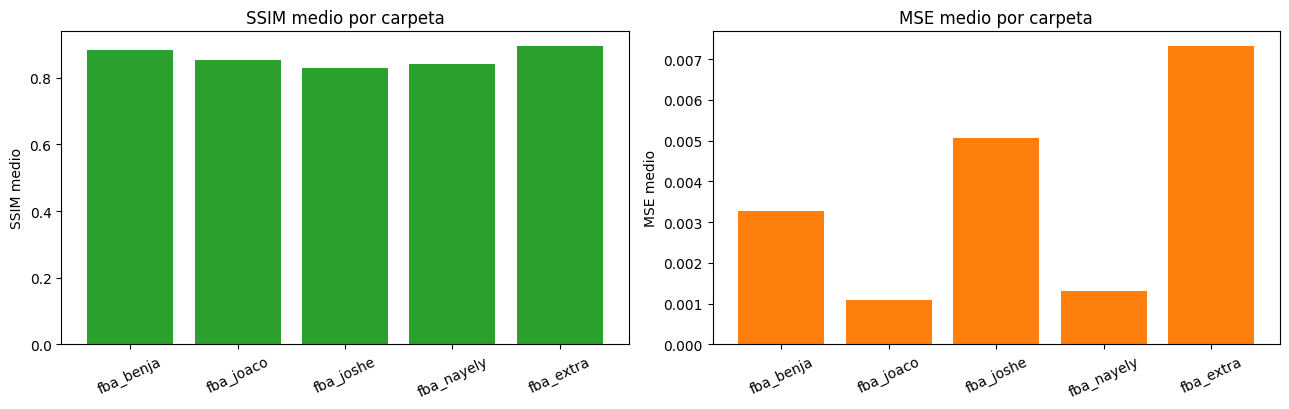

In [ ]:
resumen = []
for folder_name, df in resultados.items():
    if df.empty or not df['SSIM'].notna().any():
        continue
    resumen.append({
        'carpeta': f'{METHOD}_{short_name(folder_name)}',
        'n': int(df['SSIM'].notna().sum()),
        'MSE_medio': df['MSE'].mean(),
        'PSNR_dB_medio': df['PSNR_dB'].mean(),
        'SSIM_medio': df['SSIM'].mean(),
    })

if resumen:
    res_df = pd.DataFrame(resumen)
    print(res_df.to_string(index=False))
    res_df.to_csv(OUTPUT_ROOT / 'Promedios.csv', index=False)
    print(f'\n📄 Resumen: {(OUTPUT_ROOT / "Promedios.csv").resolve()}')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
    ax1.bar(res_df['carpeta'], res_df['SSIM_medio'], color='tab:green')
    ax1.set_ylabel('SSIM medio'); ax1.set_title('SSIM medio por carpeta')
    ax1.tick_params(axis='x', rotation=25)
    ax2.bar(res_df['carpeta'], res_df['MSE_medio'], color='tab:orange')
    ax2.set_ylabel('MSE medio'); ax2.set_title('MSE medio por carpeta')
    ax2.tick_params(axis='x', rotation=25)
    plt.tight_layout(); plt.show()
else:
    print('No hay métricas (¿las carpetas tienen MFBD?).')

## 8. Comparación visual — FBA restaurada vs MFBD

Por cada cubo muestra tres paneles lado a lado: **promedio crudo | FBA restaurada | MFBD (referencia)**, recortados al mismo campo (vía `match_template`) y con sus métricas. Configurá la carpeta y qué cubos ver.

Comparando 4 cubo(s) de "Dataset - Benjamin"  (crudo | FBA | MFBD)



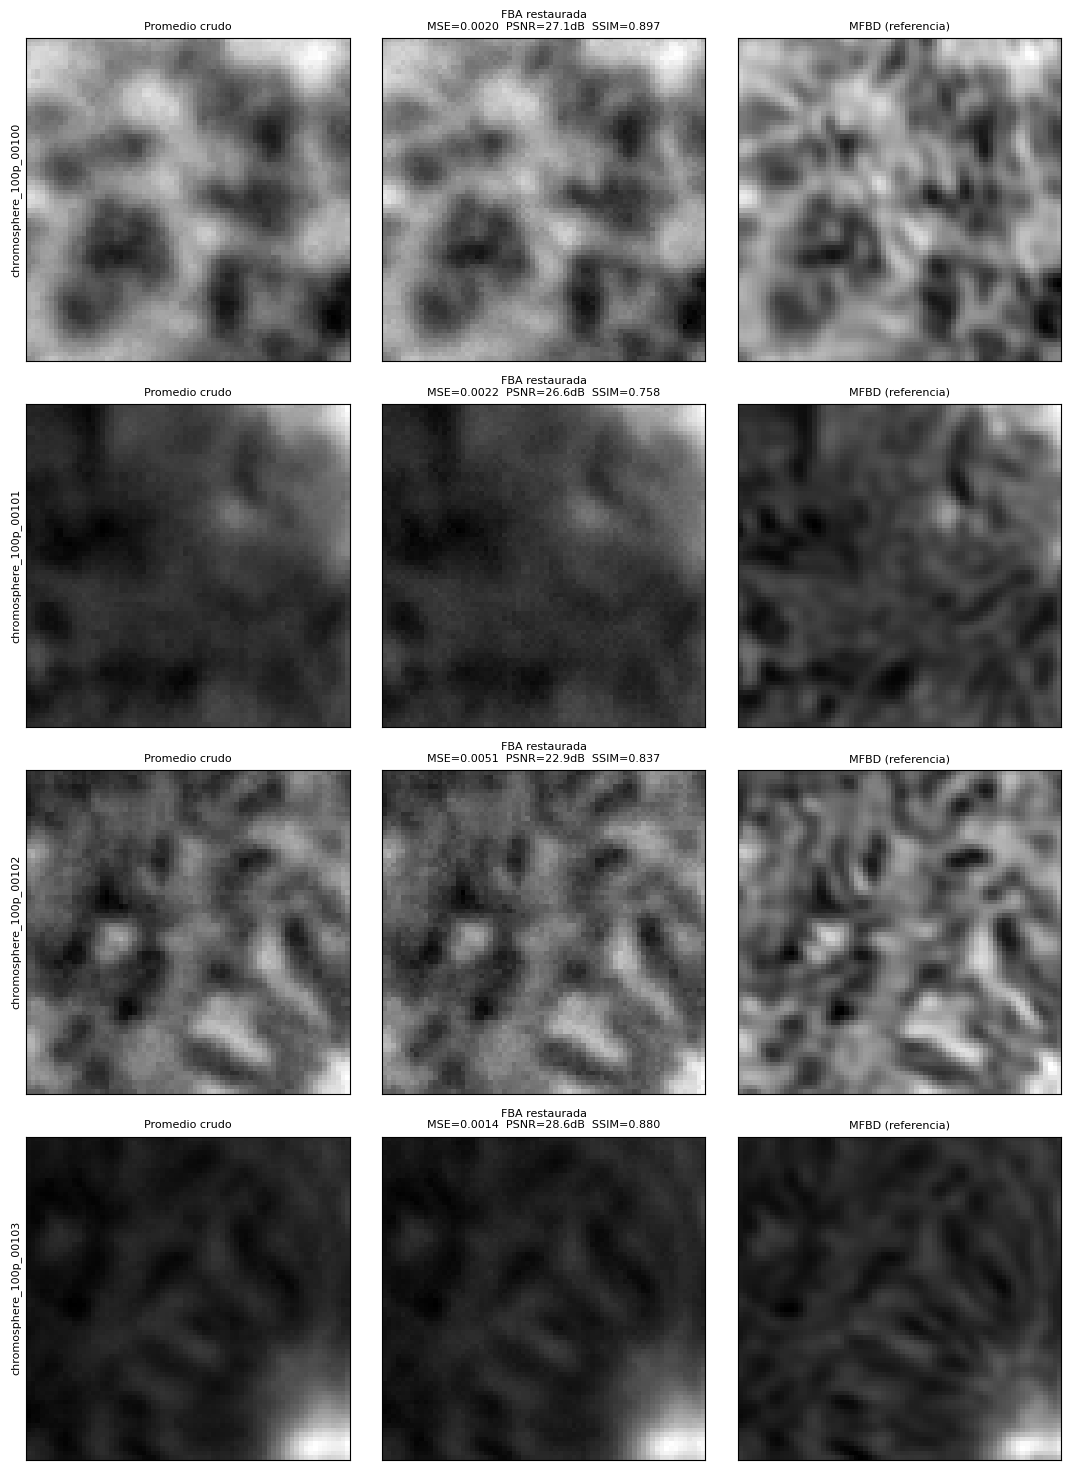

In [ ]:
# ----------------------- CONFIG COMPARACIÓN VISUAL -----------------------
CMP_FOLDER = folders[0]   # carpeta a mirar (índice 0..4; ver inventario sección 2)
CMP_IDS    = None         # lista de IDs, ej. ['00100', '00105'] ; None = primeros CMP_N
CMP_N      = 4            # nº de cubos a mostrar si CMP_IDS es None
# -------------------------------------------------------------------------

cmp_pairs = [pr for pr in discover_pairs(CMP_FOLDER) if pr['mfbd'] is not None]
if CMP_IDS is not None:
    ids = {str(x) for x in CMP_IDS}
    seleccion = [pr for pr in cmp_pairs if pr['id'] in ids]
else:
    seleccion = cmp_pairs[:CMP_N]

if not seleccion:
    print('No hay cubos para mostrar (revisá CMP_FOLDER / CMP_IDS).')
else:
    print(f'Comparando {len(seleccion)} cubo(s) de "{CMP_FOLDER.name}"  (crudo | FBA | MFBD)\n')
    n = len(seleccion)
    fig, axes = plt.subplots(n, 3, figsize=(11, 3.7 * n))
    if n == 1:
        axes = axes[np.newaxis, :]

    for r, pr in enumerate(seleccion):
        cube = load_cube(pr['raw'])
        mfbd = load_image2d(pr['mfbd'])
        fba, _ = restore_fba(cube)
        mse_v, psnr_v, ssim_v = compute_metrics(fba, mfbd)

        # Recortar crudo y FBA a la zona del MFBD para comparar el mismo campo
        mref, fba_crop = alinear_y_recortar(mfbd, fba)
        _,    raw_crop = alinear_y_recortar(mfbd, cube.mean(axis=0))

        paneles = [
            ('Promedio crudo', raw_crop),
            (f'FBA restaurada\nMSE={mse_v:.4f}  PSNR={psnr_v:.1f}dB  SSIM={ssim_v:.3f}', fba_crop),
            ('MFBD (referencia)', mref),
        ]
        for c, (titulo, img) in enumerate(paneles):
            axes[r, c].imshow(procesar_y_normalizar(img), origin='lower')
            axes[r, c].set_title(titulo, fontsize=8)
            axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
        axes[r, 0].set_ylabel(f"{pr['prefix']}_{pr['id']}", fontsize=8)

    plt.tight_layout()
    plt.show()